# Домашнее задание 2

Реализуйте:
1. **GradientBoostingMSE** - градиентный бустинг для регрессии с нуля
2. **CatBoost практика** - Pool, early stopping, сравнение бустингов

Проверка: `uv run python -m unittest tests/*.py`

In [33]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import time

from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import GradientBoostingRegressor

from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Часть 1. Gradient Boosting MSE с нуля

Gradient Boosting строит ансамбль деревьев последовательно. Каждое следующее дерево обучается предсказывать **остатки** (разницу между таргетом и текущим предсказанием ансамбля).

Алгоритм для MSE:
1. Инициализация: $F_0(x) = \bar{y}$ (среднее таргета)
2. Для $m = 1, ..., M$:
   - Вычислить остатки: $r_i = y_i - F_{m-1}(x_i)$
   - Обучить дерево $h_m$ на $(X, r)$
   - Обновить: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$
3. Предсказание: $F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} h_m(x)$

где $\eta$ - learning rate.

In [ ]:
class GradientBoostingMSE:
    def __init__(self, n_estimators=100, max_depth=3, learning_rate=0.1):
        """
        Parameters
        ----------
        n_estimators : int
            Number of boosting iterations (trees).
        max_depth : int
            Maximum depth of each tree.
        learning_rate : float
            Shrinkage parameter eta.
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate

    def fit(self, X, y):
        """
        Fit the gradient boosting model.

        Algorithm:
        1. Initialize F_0 = mean(y). Store as self.base_prediction_
        2. For each iteration:
           a. Compute residuals: r = y - current_predictions
           b. Fit a DecisionTreeRegressor(max_depth=self.max_depth) on (X, r)
           c. Store the tree in self.trees_
        3. Store training losses in self.train_losses_ (MSE at each step)

        Store:
        - self.base_prediction_ : float (mean of y)
        - self.trees_ : list of fitted DecisionTreeRegressor
        - self.train_losses_ : list of MSE values at each iteration
        """

        self.trees_ = []
        self.train_losses_ = []
        self.base_prediction_ = np.mean(y)

        current_pred = np.full(len(y), self.base_prediction_, dtype=float)

        for _ in range(self.n_estimators):

            r = y - current_pred

            model = DecisionTreeRegressor(max_depth=self.max_depth)
            model.fit(X, r)
            current_pred += self.learning_rate * model.predict(X)

            self.train_losses_.append(mean_squared_error(current_pred, y))
            self.trees_.append(model)
        return

    def predict(self, X):
        """
        Predict using the fitted model.

        prediction = base_prediction_ + learning_rate * sum(tree.predict(X) for tree in trees_)

        Returns
        -------
        np.array of shape (n_samples,)
        """

        return self.base_prediction_ + self.learning_rate * sum(tree.predict(X) for tree in self.trees_)

### Проверка GradientBoostingMSE

In [35]:
if __name__ != "homework":
    # Генерируем данные
    X_reg, y_reg = make_regression(
        n_samples=500, n_features=10, n_informative=5, noise=10.0, random_state=42,
    )
    X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42,
    )

In [36]:
if __name__ != "homework":
    # Обучаем нашу модель
    gb = GradientBoostingMSE(n_estimators=100, max_depth=3, learning_rate=0.1)
    gb.fit(X_reg_tr, y_reg_tr)
    our_preds = gb.predict(X_reg_te)
    our_mse = mean_squared_error(y_reg_te, our_preds)

    # Сравниваем со sklearn
    sk_gb = GradientBoostingRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42,
    ).fit(X_reg_tr, y_reg_tr)
    sk_mse = mean_squared_error(y_reg_te, sk_gb.predict(X_reg_te))

    print(f'Our MSE:     {our_mse:.2f}')
    print(f'sklearn MSE: {sk_mse:.2f}')
    print(f'Baseline (mean): {mean_squared_error(y_reg_te, np.full_like(y_reg_te, y_reg_tr.mean())):.2f}')

Our MSE:     331.64
sklearn MSE: 332.19
Baseline (mean): 4514.54


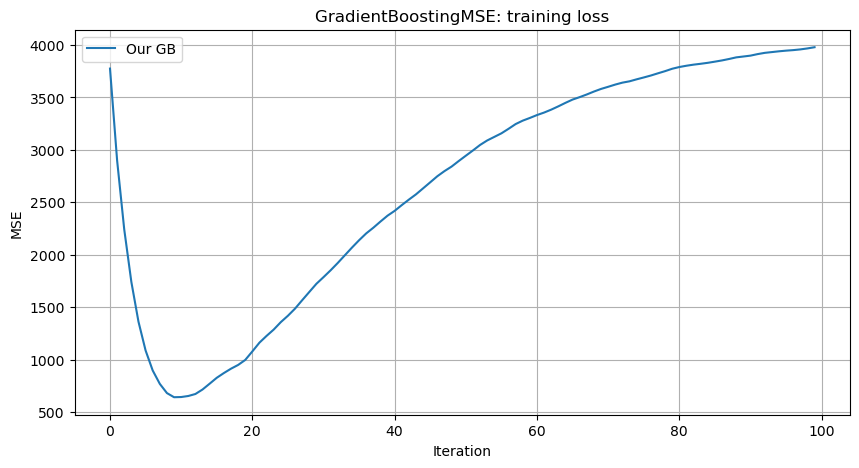

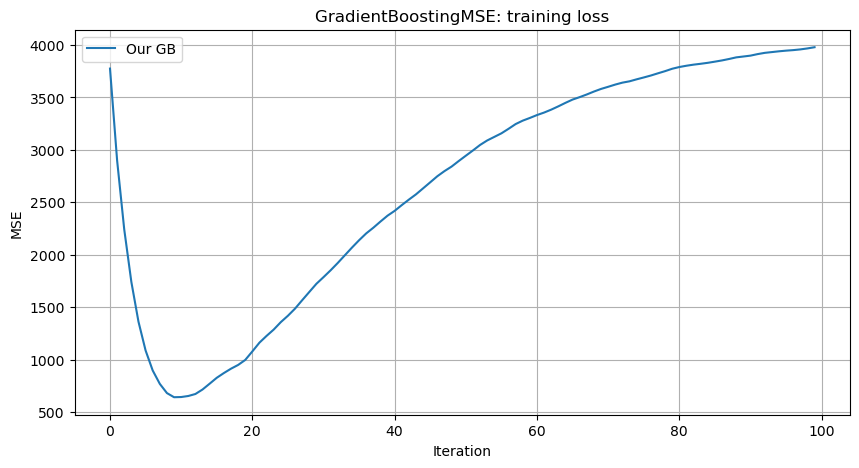

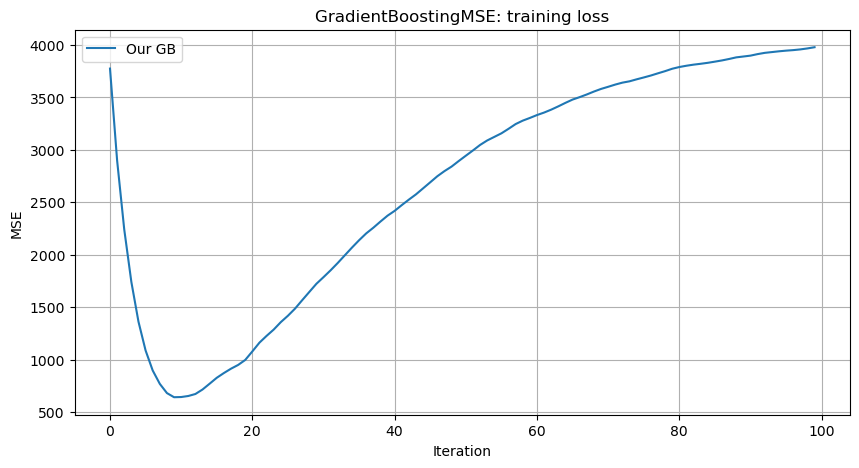

In [ ]:
if __name__ != "homework":
    # Learning curve
    plt.figure(figsize=(10, 5))
    plt.plot(gb.train_losses_, label='Our GB')
    plt.xlabel('Iteration')
    plt.ylabel('MSE')
    plt.title('GradientBoostingMSE: training loss')
    plt.legend()
    plt.grid(True)
    plt.show()

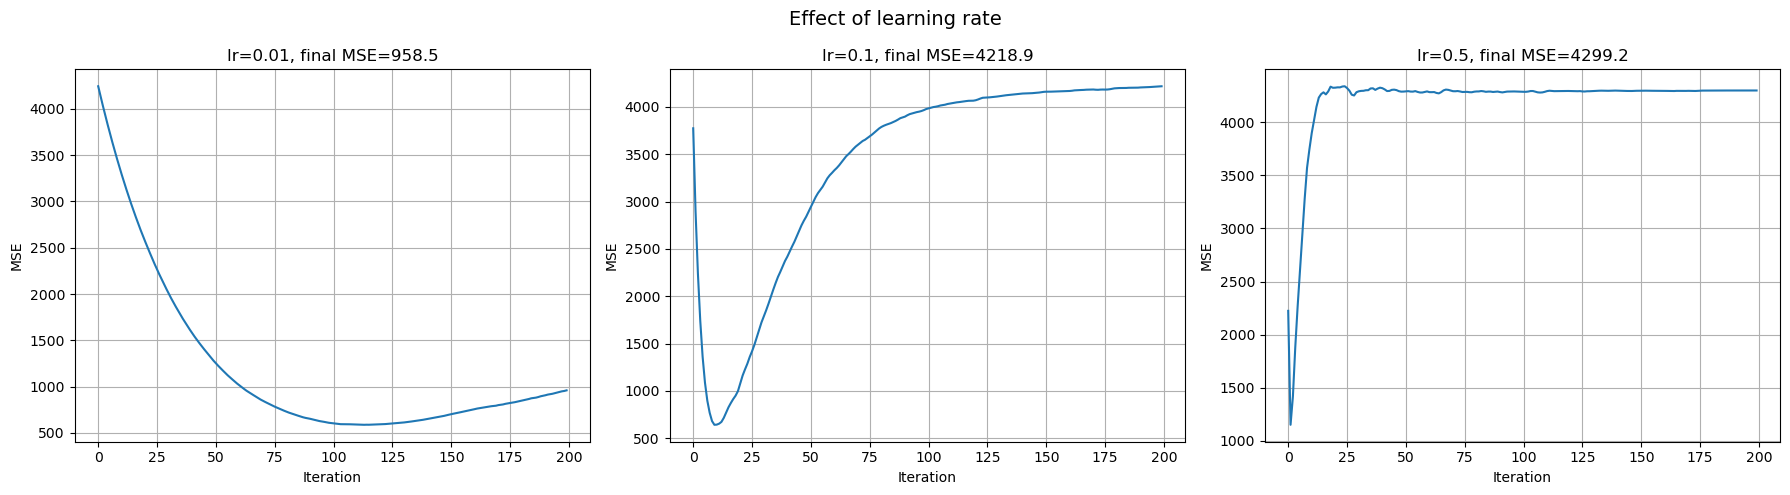

In [ ]:
if __name__ != "homework":
    # Влияние learning rate
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, lr in zip(axes, [0.01, 0.1, 0.5]):
        model = GradientBoostingMSE(n_estimators=200, max_depth=3, learning_rate=lr)
        model.fit(X_reg_tr, y_reg_tr)
        ax.plot(model.train_losses_)
        ax.set_title(f'lr={lr}, final MSE={model.train_losses_[-1]:.1f}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('MSE')
        ax.grid(True)
    plt.suptitle('Effect of learning rate', fontsize=14)
    plt.tight_layout()
    plt.show()

## Часть 2. CatBoost практика

### 2.1 Подготовка данных: CatBoost Pool

CatBoost использует собственный объект `Pool` для хранения данных. Pool позволяет указать категориальные признаки, веса объектов, и другие метаданные.

In [50]:
def prepare_catboost_pool(X_train, y_train, X_val, y_val, cat_features=None):
    """
    Create CatBoost Pool objects for training and validation.

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val : validation data
    cat_features : list of int or None
        Indices of categorical features.

    Returns
    -------
    (train_pool, val_pool) : tuple of catboost.Pool
    """
    
    train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
    val_pool = Pool(X_val, label=y_val, cat_features=cat_features)
    return (train_pool, val_pool)

### 2.2 Early stopping

Early stopping останавливает обучение, когда качество на валидации перестает расти. Это предотвращает переобучение и экономит время.

In [51]:
def train_with_early_stopping(train_pool, val_pool, iterations=1000, patience=50):
    """
    Train CatBoostClassifier with early stopping.

    Parameters
    ----------
    train_pool : catboost.Pool
    val_pool : catboost.Pool
    iterations : int
        Maximum number of iterations.
    patience : int
        early_stopping_rounds - stop if no improvement for this many rounds.

    Returns
    -------
    (model, best_iteration) : tuple
        Fitted CatBoostClassifier and the best iteration number.

    Hints:
    - Use CatBoostClassifier(iterations=iterations, verbose=False, random_state=42)
    - Pass eval_set=val_pool and early_stopping_rounds=patience to fit()
    - best_iteration is model.best_iteration_
    """
    model = CatBoostClassifier(iterations=iterations, verbose=False, random_state=42)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=patience)
    return (model, model.best_iteration_)

### Проверка early stopping

Best iteration: 399
Test accuracy:  0.8625


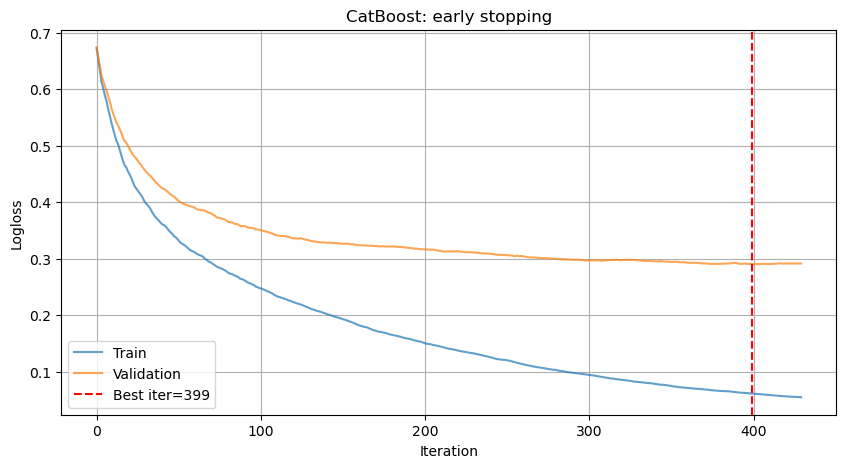

In [52]:
if __name__ != "homework":
    X_cls, y_cls = make_classification(
        n_samples=2000, n_features=15, n_informative=8,
        n_classes=2, random_state=42,
    )
    X_cls_tr, X_cls_te, y_cls_tr, y_cls_te = train_test_split(
        X_cls, y_cls, test_size=0.2, random_state=42,
    )
    X_cls_tr2, X_cls_val, y_cls_tr2, y_cls_val = train_test_split(
        X_cls_tr, y_cls_tr, test_size=0.2, random_state=42,
    )

    train_pool, val_pool = prepare_catboost_pool(
        X_cls_tr2, y_cls_tr2, X_cls_val, y_cls_val,
    )
    model_es, best_iter = train_with_early_stopping(
        train_pool, val_pool, iterations=500, patience=30,
    )

    print(f'Best iteration: {best_iter}')
    print(f'Test accuracy:  {accuracy_score(y_cls_te, model_es.predict(X_cls_te)):.4f}')

    # Plot learning curves
    evals = model_es.evals_result_
    plt.figure(figsize=(10, 5))
    plt.plot(evals['learn']['Logloss'], label='Train', alpha=0.7)
    plt.plot(evals['validation']['Logloss'], label='Validation', alpha=0.7)
    plt.axvline(x=best_iter, color='r', linestyle='--', label=f'Best iter={best_iter}')
    plt.xlabel('Iteration')
    plt.ylabel('Logloss')
    plt.title('CatBoost: early stopping')
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.3 Сравнение бустингов

Сравните CatBoost, XGBoost и LightGBM на одних и тех же данных.

In [53]:
def compare_boosters(X_train, y_train, X_test, y_test):
    """
    Train CatBoost, XGBoost, and LightGBM on the same data and compare.

    Parameters
    ----------
    X_train, y_train : training data
    X_test, y_test : test data

    Returns
    -------
    dict : {name: {'accuracy': float, 'time': float}}
        Keys: 'CatBoost', 'XGBoost', 'LightGBM'
        'accuracy': accuracy on test set
        'time': training time in seconds

    Hints:
    - CatBoostClassifier(iterations=200, verbose=False, random_state=42)
    - XGBClassifier(n_estimators=200, verbosity=0, random_state=42)
    - LGBMClassifier(n_estimators=200, verbose=-1, random_state=42)
    - Use time.time() to measure training time
    """
    models = {
        'CatBoost': CatBoostClassifier(iterations=200, verbose=False, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, verbosity=0, random_state=42),
        'LightGBM': LGBMClassifier(n_estimators=200, verbose=-1, random_state=42),
    }

    results = {}
    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start

        preds = model.predict(X_test)
        results[name] = {
            'accuracy': accuracy_score(y_test, preds),
            'time': elapsed,
        }
    return results

### Проверка сравнения бустингов

CatBoost  : accuracy=0.8775, time=0.20s
XGBoost   : accuracy=0.8750, time=0.20s
LightGBM  : accuracy=0.8800, time=0.53s


/opt/anaconda3/envs/datafusion/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


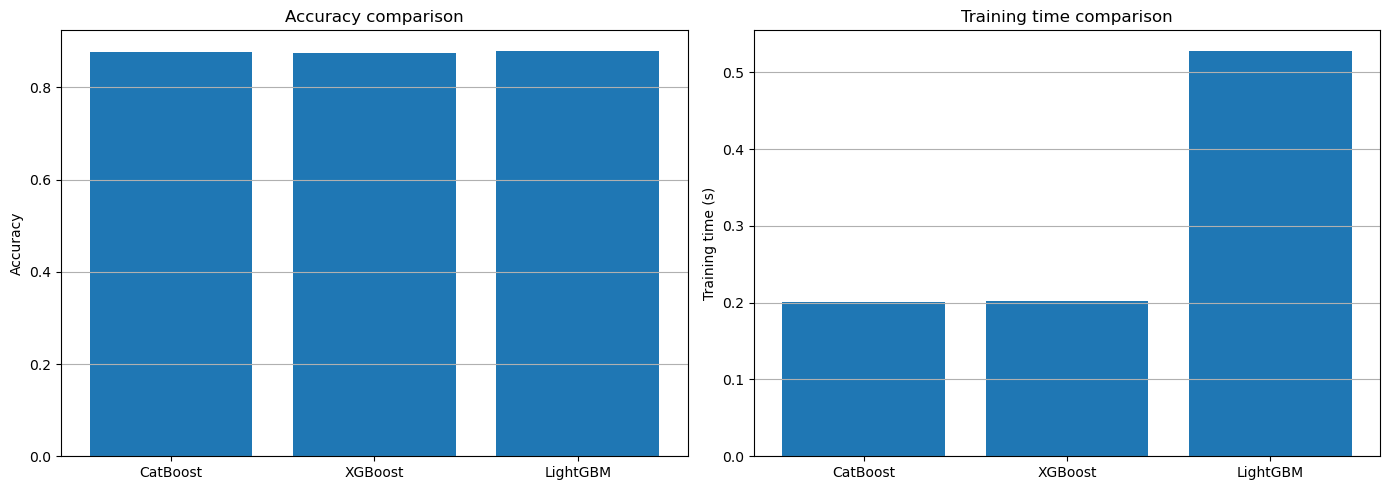

In [54]:
if __name__ != "homework":
    results = compare_boosters(X_cls_tr, y_cls_tr, X_cls_te, y_cls_te)

    for name, res in results.items():
        print(f'{name:10s}: accuracy={res["accuracy"]:.4f}, time={res["time"]:.2f}s')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = list(results.keys())
    axes[0].bar(names, [r['accuracy'] for r in results.values()])
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy comparison')
    axes[0].grid(True, axis='y')

    axes[1].bar(names, [r['time'] for r in results.values()])
    axes[1].set_ylabel('Training time (s)')
    axes[1].set_title('Training time comparison')
    axes[1].grid(True, axis='y')

    plt.tight_layout()
    plt.show()